# 1. Answer the questions

## 1.a. Получите аналитичсекое решение задачи регрессии, используя векторную форму уравнения.

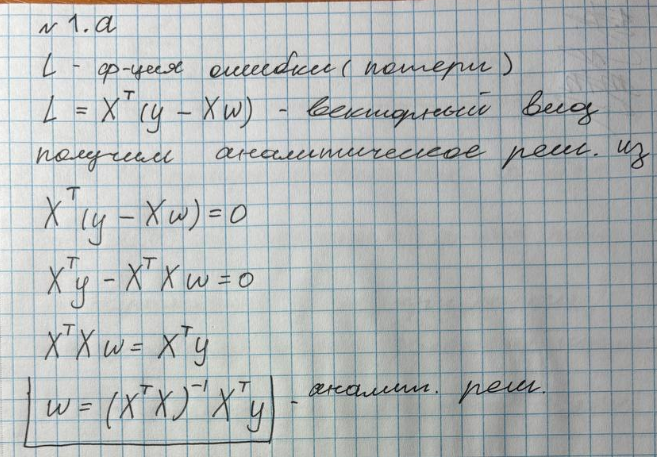

## 1.b. Что меняется в решении при добавлении регуляризаций L1 и L2 к функции потерь?

В общес случае при регуляризации к функции ошибки прибавляется регуляризационный член.

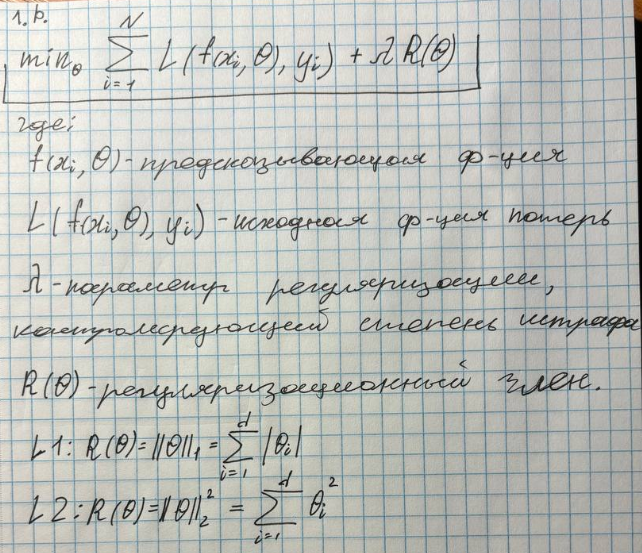

В случае линейной регрессии, L1 регуляризация позволяет отбирать наиболее значимые признаки, когда данные представленны в многомерном пространесвте, и непонятно какие признаки нужны, а какие не очень.

L2 регуляризация позволяет справитсья с мультиколлинеарностью в данных.

## 1.c. Объясните, почему для выбора объектов часто используется регуляризация L1. Почему после подгонки модели многие значения весов равны 0

L1 регуляризация добавлят к фукнции потерь 

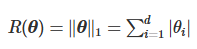

Итак почему же эта регуляризация обнуляет некоторые признаки. Если рассматривать это графически, то получтся так, что наша функция потеть предсавляет собой эллипс (если мы в двуменром пространсве), а штрафы от регуляризации имеют вид ромба. Тогда точка пересечения ромба и эллипса и будет решение, и эта точка пересецения будет чаще всего в каком то углу ромба, а в этом углу какой то параметр равен нулю. В многомерном же пространсвет у нас будет гипер-ромб, и тогда в точке пересечения в углу будет уже несколько нулевых признаков.

Либо аналитичсеки если рассматривать, то там надо уменшить штраф от регуляризации, а для этого надо обнулять какие то парамтеры и лучше всего будет обнулять те переметры, которые меньше всего вляют на решение. А насколько строгим будет отбор признаков влияет параметр λ, чем он меньше, тем меньше признаков обнулиться.


## 1.d. Объясните, как вы можете использовать одни и те же модели (линейная регрессия, гребень и т.д.), но при этом учитывать нелинейные зависимости.

Для этого можно использовать полиномиальные признаки(то есть степень признака или его произведение с другими признаками) или же использовать log, sin, cos, tg, exp или другие функции, для работы с нелинейными зависимостями.

# 2. Introduction

In [1]:
import pandas as pd
import numpy as np
import scipy
import statsmodels
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PolynomialFeatures

from collections import Counter

### Read train and test and preprocessing data

In [2]:
df_train = pd.read_json('data/train.json')
df_test = pd.read_json('data/test.json')

In [3]:
interest_level_dict_encode = {
    'low' : 0,
    'medium' : 1,
    'high' : 2
}
df_train['interest_level'] = [interest_level_dict_encode[x] for x in df_train.interest_level]

# 3. Intro data analysis part 2

### 3.i. Рассмотрим столбец features, чтобы сгенерировать дополнительные характеристики.

In [4]:
df_train['features']

4         [Dining Room, Pre-War, Laundry in Building, Di...
6         [Doorman, Elevator, Laundry in Building, Dishw...
9         [Doorman, Elevator, Laundry in Building, Laund...
10                                                       []
15        [Doorman, Elevator, Fitness Center, Laundry in...
                                ...                        
124000              [Elevator, Dishwasher, Hardwood Floors]
124002    [Common Outdoor Space, Cats Allowed, Dogs Allo...
124004    [Dining Room, Elevator, Pre-War, Laundry in Bu...
124008    [Pre-War, Laundry in Unit, Dishwasher, No Fee,...
124009    [Dining Room, Elevator, Laundry in Building, D...
Name: features, Length: 49352, dtype: object

### 3.ii. Удалим неиспользуемые символы из столбца

In [5]:
def del_symbols(list_of_features):
    for i in range(len(list_of_features)):
        list_of_features[i] = list_of_features[i].replace('[', '').replace(']', '').replace('\'', '').replace('\"', '').replace(' ', '')
    return list_of_features

In [6]:
del_symbols(df_train['features'][4])

['DiningRoom',
 'Pre-War',
 'LaundryinBuilding',
 'Dishwasher',
 'HardwoodFloors',
 'DogsAllowed',
 'CatsAllowed']

In [7]:
df_train['features'] = df_train['features'].apply(del_symbols)

### 3.iii. Получить все значениея из каждого списка и объединить результаты в одни большой список

In [8]:
all_features = []
for index, row in df_train.iterrows():
    for feature in row['features']:
        all_features.append(feature)

### 3.iv. Сколько уникальных значений содержит список результатов ?

In [9]:
len(pd.Series(all_features).unique())

1546

### 3.v. Работа с библиотекой Collections (в данном случае с Counter)

### 3.vi Посчиталь количество для каждой функции и вывести топ 20 по количеству.

In [10]:
c = Counter(all_features)
c.most_common(20)

[('Elevator', 25915),
 ('CatsAllowed', 23540),
 ('HardwoodFloors', 23527),
 ('DogsAllowed', 22035),
 ('Doorman', 20898),
 ('Dishwasher', 20426),
 ('NoFee', 18062),
 ('LaundryinBuilding', 16344),
 ('FitnessCenter', 13252),
 ('Pre-War', 9148),
 ('LaundryinUnit', 8738),
 ('RoofDeck', 6542),
 ('OutdoorSpace', 5268),
 ('DiningRoom', 5136),
 ('HighSpeedInternet', 4299),
 ('Balcony', 2992),
 ('SwimmingPool', 2730),
 ('LaundryInBuilding', 2593),
 ('NewConstruction', 2559),
 ('Terrace', 2283)]

### 3.viii. Теперь надо создать 20 новых признаков в данных.

In [11]:
names_of_new_features = [x[0] for x in c.most_common(20)]

In [12]:
for new_feature in names_of_new_features:
    is_in_feature = []
    counter = 0
    for features in df_train.features:
        counter +=1
        if new_feature in features:
            is_in_feature.append(1)
        else: 
            is_in_feature.append(0)
    df_train[new_feature] = is_in_feature

In [13]:
for new_feature in names_of_new_features:
    is_in_feature = []
    counter = 0
    for features in df_test.features:
        counter +=1
        if new_feature in features:
            is_in_feature.append(1)
        else: 
            is_in_feature.append(0)
    df_test[new_feature] = is_in_feature

### 3.ix. Расширить набор признаков, добавив ванные и спальни

In [14]:
feature_list = ['bathrooms', 'bedrooms']
for feature in names_of_new_features:
    feature_list.append(feature)
feature_list

['bathrooms',
 'bedrooms',
 'Elevator',
 'CatsAllowed',
 'HardwoodFloors',
 'DogsAllowed',
 'Doorman',
 'Dishwasher',
 'NoFee',
 'LaundryinBuilding',
 'FitnessCenter',
 'Pre-War',
 'LaundryinUnit',
 'RoofDeck',
 'OutdoorSpace',
 'DiningRoom',
 'HighSpeedInternet',
 'Balcony',
 'SwimmingPool',
 'LaundryInBuilding',
 'NewConstruction',
 'Terrace']

In [15]:
df_test.bathrooms.unique()

array([  1. ,   2. ,   3.5,   1.5,   4. ,   3. ,   0. ,   2.5,  20. ,
         4.5,   5. ,   6. ,   5.5, 112. ,   7.5,   6.5])

In [16]:
df_train = df_train[(df_train.price < np.percentile(df_train.price, 99)) & (df_train.price > np.percentile(df_train.price, 1))]
df_test = df_test[(df_test.price < np.percentile(df_test.price, 99)) & (df_test.price > np.percentile(df_test.price, 1))]
df_test = df_test[df_test.bathrooms < 6.1]

In [17]:
X_train = df_train[feature_list]
X_test = df_test[feature_list]

y_train = df_train['price']
y_test = df_test['price']

# 4. Models implementation - Linear regression

### 4.i. Инициализируйте генератор случайных чисел начальным числом 21

In [18]:
np.random.seed(21)

In [19]:
np.ones((X_train.shape[0], 1)).shape

(48343, 1)

In [20]:
np.array(y_train).reshape(-1,1)

array([[2400],
       [3800],
       [3495],
       ...,
       [1850],
       [4195],
       [4280]], dtype=int64)

### 4.ii. Реализовать собственный класс в питоне для линейной регрессии, реализовать методы fit и predict. Для подбора опитмальных парамтеров использовать стохастический градиентый спуск.

In [ ]:
class MyLinearRegression:
    def __init__(self, method='sgd', learn_rate=0.001, n_iter=100, penalty=None, lambda_=1.0, tolerance=1e-06, batch_size=1, random_state=21):
        self.method = method
        self.learn_rate=learn_rate
        self.n_iter=n_iter
        self.penalty=penalty
        self.tolerance=tolerance
        self.batch_size=batch_size
        self.rng = np.random.default_rng(seed=random_state)
        self.lambda_=lambda_
    
    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1] + 1)
        X = np.hstack((np.ones((X.shape[0], 1)), X))

        if self.method == 'sgd':
            self.sgd(X, y)
        elif self.method == 'analytic':
            self.analytic(X, y)
        elif self.method == 'nsgd':
            self.nsgd(X, y)

    def analytic(self, X, y):
        self.weights = np.linalg.inv(X.T @ X) @ X.T @ y

    def nsgd(self, X, y):
        N = X.shape[0]
        for i in range(self.n_iter):
            f = X.dot(self.weights)
            err = f - y
            grad = 2 * X.T.dot(err) / N
            self.weights -= self.learn_rate * grad
        print(self.weights)


    def sgd(self, X, y):
        n_obs = X.shape[0]
        xy = np.hstack((X, np.array(y).reshape(-1,1)))
        
        for _ in range(self.n_iter):
            self.rng.shuffle(xy)

            for start in range(0, n_obs, self.batch_size):
                stop = start + self.batch_size
                X_batch, y_batch = xy[start:stop, :-1], xy[start:stop, -1:]

                grad = self.gradient(X_batch, y_batch).reshape(-1)

                if self.penalty == 'l2':
                    grad += (2 * self.lambda_ * self.weights) / n_obs
                elif self.penalty == 'l1':
                    grad += (self.lambda_ * np.sign(self.weights)) / n_obs
                elif self.penalty == 'elasticnet':
                    l1_ratio=0.5
                    grad += ((1 - l1_ratio) * (2 * self.lambda_ * self.weights) * l1_ratio * (self.lambda_ * np.sign(self.weights))) / n_obs

                diff = -self.learn_rate * grad

                if np.all(np.abs(diff) <= self.tolerance):
                    break
                
                self.weights += diff

    def gradient(self, X, y):
        N = X.shape[0]
        f = X.dot(self.weights)
        err = f - y
        grad = 2 * X.T.dot(err) / N
        return grad

    def predict(self, X):
        X = np.hstack((np.ones((X.shape[0], 1)), X))
        return X @ self.weights

In [22]:
myLinReg = MyLinearRegression(method='analytic')
myLinReg.fit(X_train, y_train)
predict = myLinReg.predict(X_test)

print(f'MAE = {mean_absolute_error(y_test, predict)}')
print(f'RMSE = {root_mean_squared_error(y_test, predict)}')

MAE = 756.1998670813323
RMSE = 1055.447578096494


### 4.iii. What is determenistic model ? Make SGD determenistic.

Детерменирвоанные модели, это модели, которые на одних и тех же данных дают одни и те же результаты, то есть сколько бы раз мы не делали предсказания на данных, каждый раз ответ будет один и тот же. Это детерменированность в предсказании.

Есть ещё понятие детерменированности в обучении. В стохастичсеком градиентном спуске оснонвое действие в ранодном выборе пример для обучения, но его тоже можно сделать детерменированным, если задать определённый сид для рандома. В таком случае если мы будет подавать одни и те же обучающие данные, то наша модель будет одинакого опбучться и получаить, в случае линейной регресии, одни и те же значения весов модели.

### 4.iv. Определите коэффициент R в квадрате (R2) и реализуйте функцию для его вычисления.

In [23]:
def r2_coef(y_true, y_pred, y_mean):
    ssr = np.sum((y_true - y_pred)**2)
    sst = np.sum((y_true - y_mean)**2)
    return 1 - ssr / sst

In [24]:
def print_metrics(y_true, y_pred):
    print(f'MAE  = {mean_absolute_error(y_true, y_pred)}')
    print(f'RMSE = {root_mean_squared_error(y_test, predict)}')
    print(f'R2 = {r2_coef(y_test, predict, y_train.mean())}')

### 4.v. Make predictions with your algorithm and estimate the model with MAE, RMSE and R2 metrics.

In [25]:
myLinReg = MyLinearRegression(method='sgd')
myLinReg.fit(X_train, y_train)

In [26]:
predict_test = myLinReg.predict(X_test)
predict_train = myLinReg.predict(X_train)

In [27]:
print('For train data:')
print_metrics(y_train, predict_train)

print('For test data:')
print_metrics(y_test, predict_test)

For train data:
MAE  = 717.0938470831481
RMSE = 1055.447578096494
R2 = 0.5498659784382837
For test data:
MAE  = 766.0005210213329
RMSE = 1055.447578096494
R2 = 0.5498659784382837


### 4.vi. Initialize LinearRegression() from sklearn.linear_model, fit the model, and predict the training and test parts as in the previous lesson.

In [28]:
LinReg = LinearRegression()
LinReg.fit(X_train, y_train)

predict_train = LinReg.predict(X_train)
predict_test = LinReg.predict(X_test)

print('For train data:')
print_metrics(y_train, predict_train)

print('For test data:')
print_metrics(y_test, predict_test)

For train data:
MAE  = 708.7371183299155
RMSE = 1055.447578096494
R2 = 0.5498659784382837
For test data:
MAE  = 756.1998670813323
RMSE = 1055.447578096494
R2 = 0.5498659784382837


### 4.vii. Compare the quality metrics and make sure the difference is small (between your implementations and sklearn).

При сравнении видим, что показатели практически не отличаются, а точнее различия меньше чем на 1%, значит реализованный класс и метода работают корректно.

### 4.viii. Store the metrics as in the previous lesson in a table with columns model, train, test for MAE table, RMSE table, and R2 coefficient.

In [29]:
result_MAE = pd.DataFrame(columns=['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns=['model', 'train', 'test'])
result_r2 = pd.DataFrame(columns=['model', 'train', 'test'])

In [30]:
def add_writing(name_of_model, y_train_true, y_train_pred, y_test_true, y_test_pred, result_MAE=result_MAE, result_RMSE=result_RMSE, result_r2=result_r2):
    mae_df = pd.DataFrame({
        'model' : [name_of_model],
        'train' : [mean_absolute_error(y_train_true, y_train_pred)],
        'test' : [mean_absolute_error(y_test_true, y_test_pred)]
    })

    rmse_df = pd.DataFrame({
        'model' : [name_of_model],
        'train' : [root_mean_squared_error(y_train_true, y_train_pred)],
        'test' : [root_mean_squared_error(y_test_true, y_test_pred)]
    })

    r2_df = pd.DataFrame({
        'model' : [name_of_model],
        'train' : [r2_coef(y_train_true, y_train_pred, y_train_true.mean())],
        'test' : [r2_coef(y_test_true, y_test_pred, y_train_true.mean())]
    })

    result_MAE = pd.concat([result_MAE, mae_df], ignore_index=True)
    result_RMSE = pd.concat([result_RMSE, rmse_df], ignore_index=True)
    result_r2 = pd.concat([result_r2, r2_df], ignore_index=True)
    
    return result_MAE, result_RMSE, result_r2

In [31]:
result_MAE, result_RMSE, result_r2 = add_writing('Linreg default', y_train, predict_train, y_test, predict_test, result_MAE, result_RMSE, result_r2)

C:\Users\User\AppData\Local\Temp\ipykernel_4064\3392129790.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_MAE = pd.concat([result_MAE, mae_df], ignore_index=True)
C:\Users\User\AppData\Local\Temp\ipykernel_4064\3392129790.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_RMSE = pd.concat([result_RMSE, rmse_df], ignore_index=True)
C:\Users\User\AppData\Local\Temp\ipykernel_4064\3392129790.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA ent

In [32]:
print(result_MAE,'\n')
print(result_RMSE,'\n')
print(result_r2,'\n')

            model       train        test
0  Linreg default  708.737118  756.199867 

            model        train         test
0  Linreg default  1027.262879  1055.447578 

            model     train      test
0  Linreg default  0.580269  0.549866 



# 5. Regularized models implementation - Ridge, Lasso, ElasticNet

### 5.i. Implement Ridge, Lasso, ElasticNet algorithms: extend the loss function with L2, L1 and both regularizations accordingly.

Данные регуляризации будут дописаны в классе линейной регрессии.

### 5.ii. Make predictions with your algorithm and estimate the model with MAE, RMSE and R2 metrics.

In [33]:
ridge_model = MyLinearRegression(penalty='l2')
ridge_model.fit(X_train, y_train)

In [34]:
ridge_predict_train = ridge_model.predict(X_train)
ridge_predict_test = ridge_model.predict(X_test)

In [35]:
print('Ridge For train data:')
print_metrics(y_train, ridge_predict_train)

print('Ridge For test data:')
print_metrics(y_test, ridge_predict_test)

Ridge For train data:
MAE  = 717.0893287139487
RMSE = 1055.447578096494
R2 = 0.5498659784382837
Ridge For test data:
MAE  = 765.9752824069175
RMSE = 1055.447578096494
R2 = 0.5498659784382837


In [36]:
lasso_model = MyLinearRegression(penalty='l1')
lasso_model.fit(X_train, y_train)

In [37]:
lasso_predict_train = lasso_model.predict(X_train)
lasso_predict_test = lasso_model.predict(X_test)

In [38]:
print('lasso For train data:')
print_metrics(y_train, lasso_predict_train)

print('lasso For test data:')
print_metrics(y_test, lasso_predict_test)

lasso For train data:
MAE  = 717.0938421854893
RMSE = 1055.447578096494
R2 = 0.5498659784382837
lasso For test data:
MAE  = 766.0004765428765
RMSE = 1055.447578096494
R2 = 0.5498659784382837


In [39]:
elasticnet_model = MyLinearRegression(penalty='elasticnet')
elasticnet_model.fit(X_train, y_train)

In [40]:
elasticnet_predict_train = elasticnet_model.predict(X_train)
elasticnet_predict_test = elasticnet_model.predict(X_test)

In [41]:
print('elasticnet For train data:')
print_metrics(y_train, elasticnet_predict_train)

print('elasticnet For test data:')
print_metrics(y_test, elasticnet_predict_test)

elasticnet For train data:
MAE  = 717.0931483080687
RMSE = 1055.447578096494
R2 = 0.5498659784382837
elasticnet For test data:
MAE  = 765.9996480067816
RMSE = 1055.447578096494
R2 = 0.5498659784382837


### 5.iii. Initialize Ridge(), Lasso(), and ElasticNet() from sklearn.linear_model, fit the model, and make predictions for the training and test samples as in the previous lesson.

In [42]:
models = [Ridge(), Lasso(), ElasticNet()]
names_of_models = ['Ridge default', 'Lasso default', 'ElasticNet Default']

for i in range(3):
    models[i].fit(X_train, y_train)
    predict_train = models[i].predict(X_train)
    predict_test = models[i].predict(X_test)

    print(f'{names_of_models[i]} for train data')
    print_metrics(y_train, predict_train)

    print(f'{names_of_models[i]} for test data')
    print_metrics(y_test, predict_test)

    print('')

Ridge default for train data
MAE  = 708.7341747710091
RMSE = 1055.447578096494
R2 = 0.5498659784382837
Ridge default for test data
MAE  = 756.1852891910869
RMSE = 1055.447578096494
R2 = 0.5498659784382837

Lasso default for train data
MAE  = 708.3833670926889
RMSE = 1055.447578096494
R2 = 0.5498659784382837
Lasso default for test data
MAE  = 752.9710706469905
RMSE = 1055.447578096494
R2 = 0.5498659784382837

ElasticNet Default for train data
MAE  = 804.2987953715123
RMSE = 1055.447578096494
R2 = 0.5498659784382837
ElasticNet Default for test data
MAE  = 802.5768559100032
RMSE = 1055.447578096494
R2 = 0.5498659784382837



### 5.v. Store the metrics in a tables

In [43]:
models = [Ridge(), Lasso(), ElasticNet()]
names_of_models = ['Ridge default', 'Lasso default', 'ElasticNet Default']

for i in range(3):
    models[i].fit(X_train, y_train)
    predict_train = models[i].predict(X_train)
    predict_test = models[i].predict(X_test)

    result_MAE, result_RMSE, result_r2 = add_writing(names_of_models[i], y_train, predict_train, y_test, predict_test, result_MAE, result_RMSE, result_r2)

In [44]:
def results_print():
    print('MAE:\n',result_MAE,'\n')
    print('RMSE:\n',result_RMSE,'\n')
    print('R2:\n',result_r2,'\n')


In [45]:
results_print()

MAE:
                 model       train        test
0      Linreg default  708.737118  756.199867
1       Ridge default  708.734175  756.185289
2       Lasso default  708.383367  752.971071
3  ElasticNet Default  804.298795  802.576856 

RMSE:
                 model        train         test
0      Linreg default  1027.262879  1055.447578
1       Ridge default  1027.262884  1055.442901
2       Lasso default  1027.454727  1054.037534
3  ElasticNet Default  1180.302856  1202.368294 

R2:
                 model     train      test
0      Linreg default  0.580269  0.549866
1       Ridge default  0.580269  0.549870
2       Lasso default  0.580112  0.551068
3  ElasticNet Default  0.445892  0.415824 



# 6. Feature normalization

### 6.i. First, write several examples of why and where feature normalization is mandatory and vice versa.

Когда нужна нормализация данных:

Когда данные имеют сильно разный масштаб, тогда те признаки, которые численно имеют большие значени будут сильнее влиять на резульат модели, хотя в действистельности это может быть не так. В таком случае важно, особенно для градиентного спуска, чтобы все признаки имели одинаковый масштаб, например лежали в пределах [0, 1] или [-1, 1]. В таком случае все признаки изначально будут иметь одинаковое влияение, и можно будет выявить правильные закономерности. Также это ускорят сходимость градиентного спуска, так как спус происходит перпендикулярно линиям уровня, то при разной размерности спуск будет дольше.

Итак самое главное, где надо использовать нормализацию - это когда данные имеют разный масштаб, напирмер, количество передач автомобиля масиум 6-7, максимальная скороость пару сотен, а вес в килограммах будет до 2000, а максимальные обороты двигателя несоклко тысяч. Тут важно будет номальизовать данные.

Когда не нужно нормализовывать данные:

Ну самый тривильный пример - когда только один признак, тут очевдино нет смысла ничего номральизоваывать.

Если признаки луежат в одинаковых диапазонах, например есть у нас есть набор оценок продукта по 5ти бальной шкале, например, оценка цены, качества, работы прибора и ещё несколько. В таком случае наши данные лежат в одинаковом диапзоне. То есть данные изначлаьно имеют одинаковые условия влияния на результат, и смысла в нормализации нет.

Также нет смысла в номрализации для категорильных признаков, так как там значение является только индекатором того, что данный признак присутсвует, и смысла проводить на нём нормлаизации нет.

### 6.ii. Let's consider the first of the classical normalization methods — MinMaxScaler. Write a mathematical formula for this method.

x_scaled = (x - min) / (max - min)

x - исходное значение

min - минимальное значение

msx - максимальное значение

### 6.iii. Implement your own function or class for MinMaxScaler feature normalization.

In [46]:
def MyMinMaxScaler(X):
    arr = np.array(X)
    answer = np.empty(arr.shape)
    for i in range(arr.shape[1]):
        min = arr[:,i].min()
        max = arr[:,i].max()
        for j in range(arr.shape[0]):
            answer[j,i] = (arr[j,i] - min) / (max - min)
    
    return answer

### 6.iv. Initialize MinMaxScaler() from sklearn.preprocessing.
### 6.v. Compare the feature normalization with your own method and with sklearn.

In [47]:
print(MyMinMaxScaler(X_train))

[[0.1   0.125 0.    ... 0.    0.    0.   ]
 [0.1   0.25  1.    ... 0.    0.    0.   ]
 [0.1   0.25  1.    ... 0.    0.    0.   ]
 ...
 [0.1   0.125 1.    ... 0.    0.    0.   ]
 [0.1   0.25  0.    ... 0.    0.    0.   ]
 [0.1   0.375 1.    ... 0.    0.    0.   ]]


In [48]:
minmax = MinMaxScaler()
minmax.fit(X_train)
print(minmax.transform(X_train))

[[0.1   0.125 0.    ... 0.    0.    0.   ]
 [0.1   0.25  1.    ... 0.    0.    0.   ]
 [0.1   0.25  1.    ... 0.    0.    0.   ]
 ...
 [0.1   0.125 1.    ... 0.    0.    0.   ]
 [0.1   0.25  0.    ... 0.    0.    0.   ]
 [0.1   0.375 1.    ... 0.    0.    0.   ]]


### 6.vi. Repeat the steps from b to e for another normalization method StandardScaler.

Формула:

z = (x - u) / s

x - исходное занчение

u - среднее значение

s - стандартное отклонение

In [49]:
def MyStandartScaler(X):
    arr = np.array(X)
    answer = np.zeros(arr.shape)
    for i in range(arr.shape[1]):
        u = arr[:,i].mean()
        s = arr[:,i].std()
        for j in range(arr.shape[0]):
            answer[j,i] = (arr[j,i] - u) / s
    
    return answer

In [50]:
print(MyStandartScaler(X_train))

[[-0.42728906 -0.4850753  -1.05109371 ... -0.23666054 -0.233722
  -0.21715413]
 [-0.42728906  0.42295936  0.95138996 ... -0.23666054 -0.233722
  -0.21715413]
 [-0.42728906  0.42295936  0.95138996 ... -0.23666054 -0.233722
  -0.21715413]
 ...
 [-0.42728906 -0.4850753   0.95138996 ... -0.23666054 -0.233722
  -0.21715413]
 [-0.42728906  0.42295936 -1.05109371 ... -0.23666054 -0.233722
  -0.21715413]
 [-0.42728906  1.33099403  0.95138996 ... -0.23666054 -0.233722
  -0.21715413]]


In [51]:
stScal = StandardScaler()
stScal.fit(X_train)
print(stScal.transform(X_train))

[[-0.42728906 -0.4850753  -1.05109371 ... -0.23666054 -0.233722
  -0.21715413]
 [-0.42728906  0.42295936  0.95138996 ... -0.23666054 -0.233722
  -0.21715413]
 [-0.42728906  0.42295936  0.95138996 ... -0.23666054 -0.233722
  -0.21715413]
 ...
 [-0.42728906 -0.4850753   0.95138996 ... -0.23666054 -0.233722
  -0.21715413]
 [-0.42728906  0.42295936 -1.05109371 ... -0.23666054 -0.233722
  -0.21715413]
 [-0.42728906  1.33099403  0.95138996 ... -0.23666054 -0.233722
  -0.21715413]]


# 7. Fit custom and sklearn moedls with normalized data

In [52]:
minmax = MinMaxScaler()
standScaler = StandardScaler()

minmax.fit(X_train)
standScaler.fit(X_train)

StandardScaler()

In [53]:
models_normalized = [LinearRegression(), Ridge(), Lasso(), ElasticNet()]
names_minmax = ['Linreg MinMaxScaler', 'Ridge MinMaxScaler', 'Lasso MinMaxScaler', 'ElasticNet MinMaxScaler']
names_standScaler = ['Linreg StandartScaler', 'Ridge StandartScaler', 'Lasso StandartScaler', 'ElasticNet StandartScaler']

In [54]:
for i in range(4):
    model = models_normalized[i]
    X_train_normalize = minmax.transform(X_train)
    X_test_normalize = minmax.transform(X_test)
    model.fit(X_train_normalize, y_train)

    predict_train = model.predict(X_train_normalize)
    predict_test = model.predict(X_test_normalize)

    result_MAE, result_RMSE, result_r2 = add_writing(names_minmax[i], y_train, predict_train, y_test, predict_test, result_MAE, result_RMSE, result_r2)

In [55]:
for i in range(4):
    model = models_normalized[i]
    X_train_normalize = standScaler.transform(X_train)
    X_test_normalize = standScaler.transform(X_test)
    model.fit(X_train_normalize, y_train)

    predict_train = model.predict(X_train_normalize)
    predict_test = model.predict(X_test_normalize)

    result_MAE, result_RMSE, result_r2 = add_writing(names_standScaler[i], y_train, predict_train, y_test, predict_test, result_MAE, result_RMSE, result_r2)

In [56]:
results_print()

MAE:
                         model        train         test
0              Linreg default   708.737118   756.199867
1               Ridge default   708.734175   756.185289
2               Lasso default   708.383367   752.971071
3          ElasticNet Default   804.298795   802.576856
4         Linreg MinMaxScaler   708.737118   756.199867
5          Ridge MinMaxScaler   708.827934   756.350786
6          Lasso MinMaxScaler   708.668995   753.366102
7     ElasticNet MinMaxScaler  1052.908180  1039.365904
8       Linreg StandartScaler   708.737118   756.199867
9        Ridge StandartScaler   708.736591   756.196418
10       Lasso StandartScaler   708.569439   754.619409
11  ElasticNet StandartScaler   739.158998   753.506713 

RMSE:
                         model        train         test
0              Linreg default  1027.262879  1055.447578
1               Ridge default  1027.262884  1055.442901
2               Lasso default  1027.454727  1054.037534
3          ElasticNet Default  11

# 8. Overfit models

### ii. Use PolynomialFeatures and get new poly dataset

In [57]:
poly = PolynomialFeatures(degree=10)

In [58]:
X_train_poly = pd.DataFrame(poly.fit_transform(X_train[['bathrooms', 'bedrooms']]), columns=poly.get_feature_names_out())
X_train_poly = pd.concat([X_train_poly.reset_index(drop=True), X_train.drop(columns=['bathrooms', 'bedrooms']).reset_index(drop=True)], axis=1)
X_train_poly

,1,bathrooms,bedrooms,bathrooms^2,bathrooms bedrooms,bedrooms^2,bathrooms^3,bathrooms^2 bedrooms,bathrooms bedrooms^2,bedrooms^3,...,LaundryinUnit,RoofDeck,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace
0,1.0,1.0,1.0,1.00,1.0,1.0,1.000,1.00,1.0,1.0,...,0,0,0,1,0,0,0,0,0,0
1,1.0,1.0,2.0,1.00,2.0,4.0,1.000,2.00,4.0,8.0,...,0,0,0,0,0,0,0,0,0,0
2,1.0,1.0,2.0,1.00,2.0,4.0,1.000,2.00,4.0,8.0,...,1,0,0,0,0,0,0,0,0,0
3,1.0,1.5,3.0,2.25,4.5,9.0,3.375,6.75,13.5,27.0,...,0,0,0,0,0,0,0,0,0,0
4,1.0,1.0,0.0,1.00,0.0,0.0,1.000,0.00,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48338,1.0,1.0,3.0,1.00,3.0,9.0,1.000,3.00,9.0,27.0,...,0,0,0,0,0,0,0,0,0,0
48339,1.0,1.0,2.0,1.00,2.0,4.0,1.000,2.00,4.0,8.0,...,0,0,0,0,0,0,0,1,0,0
48340,1.0,1.0,1.0,1.00,1.0,1.0,1.000,1.00,1.0,1.0,...,1,0,0,1,0,0,0,0,0,0
48341,1.0,1.0,2.0,1.00,2.0,4.0,1.000,2.00,4.0,8.0,...,1,0,1,0,0,0,0,0,0,0


In [59]:
X_test_poly = pd.DataFrame(poly.fit_transform(X_test[['bathrooms', 'bedrooms']]), columns=poly.get_feature_names_out())
X_test_poly = pd.concat([X_test_poly.reset_index(drop=True), X_test.drop(columns=['bathrooms', 'bedrooms']).reset_index(drop=True)], axis=1)
X_test_poly

,1,bathrooms,bedrooms,bathrooms^2,bathrooms bedrooms,bedrooms^2,bathrooms^3,bathrooms^2 bedrooms,bathrooms bedrooms^2,bedrooms^3,...,LaundryinUnit,RoofDeck,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0,0,0,0,0,0,0,0,0,0
1,1.0,1.0,2.0,1.0,2.0,4.0,1.0,2.0,4.0,8.0,...,0,0,0,0,0,0,0,0,0,0
2,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,1.0,1.0,2.0,1.0,2.0,4.0,1.0,2.0,4.0,8.0,...,0,0,0,0,0,0,0,0,0,0
4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73121,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0,0,0,0,0,0,0,0,0,0
73122,1.0,1.0,2.0,1.0,2.0,4.0,1.0,2.0,4.0,8.0,...,0,0,0,0,0,0,0,0,0,0
73123,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
73124,1.0,2.0,2.0,4.0,4.0,4.0,8.0,8.0,8.0,8.0,...,0,0,0,0,0,0,0,0,0,0


In [60]:
models = [LinearRegression(), Ridge(), Lasso(), ElasticNet()]
names_poly = ['Linreg Polynomial', 'Ridge Polynomial', 'Lasso Polynomial', 'ElasticNet Polynomial']

In [61]:
for i in range(4):
    model = models[i]
    model.fit(X_train_poly, y_train)

    predict_train = model.predict(X_train_poly)
    predict_test = model.predict(X_test_poly)

    result_MAE, result_RMSE, result_r2 = add_writing(names_poly[i], y_train, predict_train, y_test, predict_test, result_MAE, result_RMSE, result_r2)

c:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.422e+10, tolerance: 1.215e+07
  model = cd_fast.enet_coordinate_descent(
c:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.744e+10, tolerance: 1.215e+07
  model = cd_fast.enet_coordinate_descent(


In [62]:
results_print()

MAE:
                         model        train         test
0              Linreg default   708.737118   756.199867
1               Ridge default   708.734175   756.185289
2               Lasso default   708.383367   752.971071
3          ElasticNet Default   804.298795   802.576856
4         Linreg MinMaxScaler   708.737118   756.199867
5          Ridge MinMaxScaler   708.827934   756.350786
6          Lasso MinMaxScaler   708.668995   753.366102
7     ElasticNet MinMaxScaler  1052.908180  1039.365904
8       Linreg StandartScaler   708.737118   756.199867
9        Ridge StandartScaler   708.736591   756.196418
10       Lasso StandartScaler   708.569439   754.619409
11  ElasticNet StandartScaler   739.158998   753.506713
12          Linreg Polynomial   681.673489  1381.512782
13           Ridge Polynomial   682.059759  1010.279951
14           Lasso Polynomial   686.784203   722.481630
15      ElasticNet Polynomial   719.654398   724.487241 

RMSE:
                         model    

# 9. Naive models

In [63]:
y_train.shape

(48343,)

In [64]:
predict_train_mean = np.full(y_train.shape, y_train.mean())
predict_test_mean = np.full(y_test.shape, y_train.mean())

predict_train_median = np.full(y_train.shape, y_train.median())
predict_test_median = np.full(y_test.shape, y_train.median())

In [65]:
result_MAE, result_RMSE, result_r2 = add_writing('Native mean', y_train, predict_train_mean, y_test, predict_test_mean, result_MAE, result_RMSE, result_r2)
result_MAE, result_RMSE, result_r2 = add_writing('Native median', y_train, predict_train_median, y_test, predict_test_median, result_MAE, result_RMSE, result_r2)

In [66]:
results_print()

MAE:
                         model        train         test
0              Linreg default   708.737118   756.199867
1               Ridge default   708.734175   756.185289
2               Lasso default   708.383367   752.971071
3          ElasticNet Default   804.298795   802.576856
4         Linreg MinMaxScaler   708.737118   756.199867
5          Ridge MinMaxScaler   708.827934   756.350786
6          Lasso MinMaxScaler   708.668995   753.366102
7     ElasticNet MinMaxScaler  1052.908180  1039.365904
8       Linreg StandartScaler   708.737118   756.199867
9        Ridge StandartScaler   708.736591   756.196418
10       Lasso StandartScaler   708.569439   754.619409
11  ElasticNet StandartScaler   739.158998   753.506713
12          Linreg Polynomial   681.673489  1381.512782
13           Ridge Polynomial   682.059759  1010.279951
14           Lasso Polynomial   686.784203   722.481630
15      ElasticNet Polynomial   719.654398   724.487241
16                Native mean  1134.361473

# Compare results

In [67]:
results_print()

MAE:
                         model        train         test
0              Linreg default   708.737118   756.199867
1               Ridge default   708.734175   756.185289
2               Lasso default   708.383367   752.971071
3          ElasticNet Default   804.298795   802.576856
4         Linreg MinMaxScaler   708.737118   756.199867
5          Ridge MinMaxScaler   708.827934   756.350786
6          Lasso MinMaxScaler   708.668995   753.366102
7     ElasticNet MinMaxScaler  1052.908180  1039.365904
8       Linreg StandartScaler   708.737118   756.199867
9        Ridge StandartScaler   708.736591   756.196418
10       Lasso StandartScaler   708.569439   754.619409
11  ElasticNet StandartScaler   739.158998   753.506713
12          Linreg Polynomial   681.673489  1381.512782
13           Ridge Polynomial   682.059759  1010.279951
14           Lasso Polynomial   686.784203   722.481630
15      ElasticNet Polynomial   719.654398   724.487241
16                Native mean  1134.361473

### 10.b Модель Lasso является самой удоачной во всех метриках, и при этом все её вариации хороши, даже полиномиальная версия (это связано как раз такми с методом регуляризации, который позволяет бороться с переобучением, благоадря чему как такого переобучения не произошло). Поэтому назвать наилучшей моделью можно Lasso, и если смотреть прям на полученние значения, то полиномаильная модель выигрывает, однако разница не велика, и лучше будет использовать Lasso с MinMaxScaler.

### 10.c Самая стабильная модель - это ElasticNet, то есть когда используются оба метода регуляризации для регрессии. В целом это очевидно, так как методы ругляризации нужны для того, чтобы лушче обощать данные и не допускать переобучения, с чём они отлично справляются. У этой модели в разных её вариациях самое маленькое различие между показателями на тренировочной и тестовой выборках. Раза в 3 меньше различия, чем у других моделей.

# 11. Допольниктельная часть

### 11.a. Заменить целевую функцию логарифмом, чтобы сгладить данные и уменьшить действие выбросов на обучение.

In [68]:
y_train_log = np.log(y_train)
y_train_log

4         7.783224
6         8.242756
9         8.159089
10        8.006368
15        7.935587
            ...   
124000    7.937375
124002    7.781139
124004    7.522941
124008    8.341649
124009    8.361708
Name: price, Length: 48343, dtype: float64

In [69]:
models = [LinearRegression(), Ridge(), Lasso(alpha=0.05), ElasticNet(alpha=0.05)]
models_names = ['Linreg', 'Ridge', 'Lasso', 'ElasticNet']
normalizations = [None, MinMaxScaler(), StandardScaler()]
noramlizations_names = ['default', 'MinMaxScaler', 'StandardScaler']

In [70]:
result_MAE_log = pd.DataFrame(columns=['model', 'train', 'test'])
result_RMSE_log = pd.DataFrame(columns=['model', 'train', 'test'])
result_r2_log = pd.DataFrame(columns=['model', 'train', 'test'])

In [71]:
for i in range(3):
    for j in range(4):
        if not (normalizations[i] is None):
            normalize = normalizations[i]
            normalize.fit(X_train)

            X_train_normalize = normalize.transform(X_train)
            X_test_normalize = normalize.transform(X_test)

        else:
            X_train_normalize = X_train
            X_test_normalize = X_test

        model = models[j]
        model.fit(X_train_normalize, y_train_log)

        predict_train = np.exp(model.predict(X_train_normalize) + 0.5 * np.var(model.predict(X_train_normalize)))
        predict_test  = np.exp(model.predict(X_test_normalize) + 0.5 * np.var(model.predict(X_test_normalize)))

        result_MAE_log, result_RMSE_log, result_r2_log = add_writing(models_names[j] + ' ' + noramlizations_names[i], y_train, predict_train, y_test, predict_test, result_MAE_log, result_RMSE_log, result_r2_log)

C:\Users\User\AppData\Local\Temp\ipykernel_4064\3392129790.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_MAE = pd.concat([result_MAE, mae_df], ignore_index=True)
C:\Users\User\AppData\Local\Temp\ipykernel_4064\3392129790.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_RMSE = pd.concat([result_RMSE, rmse_df], ignore_index=True)
C:\Users\User\AppData\Local\Temp\ipykernel_4064\3392129790.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA ent

In [72]:
for i in range(4):
    model = models[i]
    model.fit(X_train_poly, y_train_log)

    predict_train = np.exp(model.predict(X_train_poly) + 0.5 * np.var(model.predict(X_train_poly)))
    predict_test = np.exp(model.predict(X_test_poly) + 0.5 * np.var(model.predict(X_train_poly)))

    result_MAE_log, result_RMSE_log, result_r2_log = add_writing(names_poly[i], y_train, predict_train, y_test, predict_test, result_MAE_log, result_RMSE_log, result_r2_log)

c:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.110e+03, tolerance: 7.144e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.960e+03, tolerance: 7.144e-01
  model = cd_fast.enet_coordinate_descent(


In [73]:
pd.set_option('display.float_format', '{:.10}'.format)


print('MAE:\n',result_MAE_log,'\n')
print('RMSE:\n',result_RMSE_log,'\n')
print('R2:\n',result_r2_log,'\n')

MAE:
                         model       train             test
0              Linreg default 712.5498133       762.801295
1               Ridge default 712.5467928      762.7776142
2               Lasso default 827.0178241      827.7032298
3          ElasticNet default 760.7416044       762.284886
4         Linreg MinMaxScaler 712.5498133       762.801295
5          Ridge MinMaxScaler 712.4682998      762.6977951
6          Lasso MinMaxScaler 1068.827651      1064.918487
7     ElasticNet MinMaxScaler 1007.729202      1009.349704
8       Linreg StandardScaler 712.5498133       762.801295
9        Ridge StandardScaler 712.5485587      762.7942895
10       Lasso StandardScaler 752.7462358      755.2568471
11  ElasticNet StandardScaler 730.2031958      735.2875663
12          Linreg Polynomial 687.9037169 1.459111903e+105
13           Ridge Polynomial 688.2365798       176591.865
14           Lasso Polynomial 776.3755503      778.4746079
15      ElasticNet Polynomial  735.449516      737